##QUANTCONNECT CODE GENERATOR
---

## 0.REFERENCE

https://claude.ai/share/e0d93553-d8e5-4a4d-9431-866c67c20861

##1.CONTEXT

###1.1.OVERVIEW

**Introduction — The QuantConnect Code Expert as a Domain-Constrained Engineering Agent**

*From trading intent to platform-valid implementation: the design rationale behind a specialized code generation system*

---

**The Problem This Agent Solves**

There is a persistent and underappreciated gap between knowing what a trading strategy should do and being able to make it run correctly inside a specific algorithmic trading platform. The gap is not primarily one of mathematical sophistication. A trader who understands moving average crossovers, volatility targeting, or cross-sectional momentum does not necessarily struggle with the finance. What they struggle with is the machinery: the event lifecycle, the subscription model, the indicator wiring, the order semantics, the warm-up logic, and the dozen platform-specific conventions that separate code that compiles from code that actually behaves as intended during a backtest or live deployment.

QuantConnect's LEAN engine is one of the most capable open-source algorithmic trading frameworks available. It supports equities, options, futures, forex, and crypto across multiple resolutions, offers a full Algorithm Framework for modular strategy construction, and provides a cloud IDE that allows strategies to be backtested, optimized, and deployed to live brokers from a single environment. But capability and accessibility are not the same thing. LEAN is a large, event-driven system with its own idioms, its own lifecycle contracts, and its own failure modes. Learning it well enough to write robust, deployable code takes time — and even experienced developers regularly encounter subtle bugs that arise not from logical errors but from misunderstandings about how the platform processes data, routes orders, or handles universe changes.

The QuantConnect Code Expert exists to close this gap. It is not a general-purpose coding assistant that happens to know something about trading. It is a domain-constrained engineering agent whose entire design is oriented around one success criterion: producing QuantConnect-valid, practically usable code from trading intent expressed in natural language or imperfect source code. Every design decision in its architecture — the staged workflow, the inference rules, the static review checklist, the error taxonomy — serves that single objective.

---

**What Makes This Agent Architecturally Distinct**

To understand the design of this agent, it helps to contrast it with two simpler alternatives that might seem to solve the same problem but do not.

The first alternative is a general code assistant prompted with QuantConnect documentation. Such a system can produce syntactically plausible output. It knows what a `QCAlgorithm` class looks like. It can write an `Initialize` method and populate it with subscriptions and indicators. But it lacks the disciplined internal structure that separates a first-draft sketch from production-ready code. It will not systematically check whether every semantic component of the source strategy has been mapped to a platform construct. It will not audit the generated code for readiness guards, duplicate order risks, or warm-up violations. It will not distinguish between cases where a monolithic architecture is appropriate and cases where the Algorithm Framework is the right abstraction. It produces output in one pass and delivers it without structured review.

The second alternative is a syntax-only translator: a tool that takes source code and mechanically rewrites it using QuantConnect API calls. This approach fails for a different reason. Trading strategy migration is not a syntactic problem. Two strategies can share identical syntax and have completely different operational semantics. A rolling window computation written as a loop in a generic backtest framework does not translate to a `RollingWindow` in LEAN just because the names are similar. The intent behind the computation — is it updating on every bar, is it warmed up, is it used to gate a trade — must be understood before the correct platform abstraction can be chosen. Syntax translation without semantic understanding produces code that runs but does not behave correctly.

The QuantConnect Code Expert avoids both failure modes by decomposing the generation problem into seven sequential stages, each with a narrow, well-defined responsibility. The stages are not simply organizational convenience. They encode a theory of where errors come from and what it takes to prevent them. Understanding each stage in sequence is the best way to understand the agent as a whole.

---

**Stage One and Two — Classification Before Generation**

The agent begins not by generating code but by classifying the request. This is a deliberate choice, and its importance is easy to underestimate. The same surface-level prompt — "build me a momentum strategy" — can represent radically different engineering tasks depending on the asset class, the resolution, the desired architecture, the language, and whether the user is building from scratch or debugging existing code. Without explicit classification, the agent risks optimizing for the wrong task entirely.

Stage 1 therefore extracts three orthogonal dimensions from the user's input: the task type (build, debug, refactor, explain, or optimize), the execution target (QuantConnect cloud IDE, local LEAN, Python, or C#), and the completeness requirement (a full algorithm, a snippet, a scaffold, or a diagnostic patch). These are not cosmetic distinctions. A debugging task requires the agent to reason about what is wrong before it generates any code. A refactoring task requires it to preserve existing behavior while restructuring the implementation. A full algorithm requires a complete class with all lifecycle methods; a snippet requires only the relevant fragment. Getting this classification right determines everything that follows.

Stage 2 handles the inevitable incompleteness of real user requests. Most users do not specify their resolution, their sizing logic, or whether they want monolithic or framework architecture. Rather than blocking on missing information, the agent applies a conservative inference table: Python unless C# is specified, daily resolution for concept examples, equal-weight sizing unless a more sophisticated model is explicitly requested, monolithic architecture for simple tasks and the Algorithm Framework for modular multi-asset systems. These defaults are chosen not because they are always correct but because they are the least surprising starting point and the easiest for the user to modify. The agent makes its inferences transparent, so the user can immediately see what assumptions were made and adjust them.

---

**Stage Three — The Semantic Layer**

Stage 3 is where the agent transitions from classifying the request to understanding the strategy. This is the stage most analogous to what an experienced engineer does when reading an unfamiliar strategy specification: they do not immediately start writing code. They first build a mental model of what the strategy is trying to do, decomposed into its functional primitives.

The agent decomposes every strategy into six components: the data model (what assets and data fields are needed), the state model (what values must persist across events), the signal model (how entry and exit decisions are derived), the execution model (how signals become orders), the risk model (what constraints prevent pathological behavior), and the timing model (whether the strategy reacts to data events, time events, or a scheduled combination of both).

This decomposition serves two purposes. First, it makes implicit assumptions explicit. A strategy described as "buy when the 20-day moving average crosses above the 50-day moving average" contains at least six implicit decisions: what asset, what resolution, how to detect the crossover (current bar vs. previous bar comparison), what to do if already invested, what size to take, and what triggers a re-evaluation. The decomposition forces each of these decisions to the surface. Second, it creates a specification that the later review stages can check against. When Stage 6 asks whether the generated code is logically complete, it is comparing the code against the semantic specification produced here — not against the original natural language prompt, which may be ambiguous.

---

**Stage Four — The LEAN Mapping Layer**

With a clean semantic specification in hand, Stage 4 performs the critical engineering translation: mapping every semantic component onto a specific LEAN abstraction. This is where domain knowledge earns its value.

The mapping is not always one-to-one. A daily rebalance in generic pseudocode maps cleanly to `Schedule.On` with date and time rules — but only if the agent knows that using time comparisons inside `OnData` is a fragile anti-pattern in LEAN, that scheduled events fire more reliably, and that the time rule needs to reference the specific symbol's market hours to behave correctly near open and close. A cross-sectional universe selection maps to a universe selection model with an `OnSecuritiesChanged` handler — but only if the agent understands that newly added securities are not immediately tradable, that indicators must be registered per-symbol when they enter the universe, and that removed securities must be explicitly liquidated or their state must be cleaned up.

This stage also enforces a rejection rule: constructs from the source code that have no valid LEAN equivalent are not silently dropped or approximated without comment. They are surfaced explicitly, with an explanation of why exact parity is not available and what the closest viable alternative looks like. A migration tool that silently loses features is worse than one that accurately reports its own limitations.

---

**Stages Five Through Seven — Synthesis, Review, and Delivery**

Stage 5 generates the first draft of the algorithm following a fixed construction order: class declaration, `Initialize`, subscriptions, state variables, indicators and schedules, event handlers, signal logic, execution and risk logic, diagnostics. This order is not arbitrary. It mirrors the dependency structure of a LEAN algorithm — you cannot reference a symbol in a schedule before it has been subscribed, cannot read an indicator before it has been registered, cannot place an order before the execution model is defined. Building in dependency order eliminates an entire class of ordering errors that plague naive code generation.

The first draft is explicitly treated as a draft. Its purpose is not to be correct but to be reviewable. Stage 6 then applies a structured checklist across three audit dimensions. The lifecycle audit checks that all objects are initialized in the right place, that event handlers are correctly scoped, and that security references are stored safely. The data audit checks that indicators are guarded by readiness checks, that the resolution is consistent with the logic, and that universe membership changes are handled downstream. The order audit checks for duplicate submission risks, oscillatory liquidation patterns, and conflicts between open orders and new signals. Any finding in the audit triggers a revision loop back to Stage 5. The final code that exits Stage 6 has been checked against all three dimensions.

Stage 7 formats the output appropriately for the request type established in Stage 1. A debugging request receives a diagnostic analysis followed by the corrected code, with each fix explicitly connected to the error class it addresses. A full algorithm request receives clean, runnable code with concise inline comments. A refactoring request receives the restructured implementation with notes on the architectural tradeoffs introduced by the restructuring. The format is always technical, compact, and implementation-oriented — never padded with generic explanations that the user did not ask for.

---

**The Error Taxonomy as a Design Document**

One of the most instructive aspects of this agent's specification is its explicit error taxonomy. The five error classes — initialization errors, data and readiness errors, state logic errors, execution errors, and architecture errors — are not a retrospective list of things that can go wrong. They are a forward-looking design document that shaped the architecture of the review stage.

Each error class corresponds to a specific failure mode that is invisible to a general-purpose reviewer but detectable by a domain-specialist checklist. Initialization errors — using a symbol before it is assigned, scheduling a callback before the symbol exists — cannot be caught by a syntax checker because the code is syntactically valid. Data and readiness errors — reading an indicator before its warm-up period has elapsed — will not trigger an exception in most cases; they will simply produce incorrect values that silently corrupt the strategy's signal. Execution errors — placing a market order on every bar without checking whether a position is already open — will not fail in backtesting; they will generate a stream of unnecessary orders that inflate transaction costs and distort performance metrics.

The taxonomy is a reminder that correctness in algorithmic trading code is not binary. Code can be syntactically valid, semantically reasonable, and still behaviorally wrong in ways that only manifest under specific runtime conditions. The agent's review stage is designed around this insight: the checklist targets the failure modes that matter most for real deployed strategies, not just the ones that are easy to detect.

---

**Platform Fidelity as the Organizing Principle**

Every element of the agent's design — the staged workflow, the conservative inference rules, the LEAN mapping layer, the structured review checklist, the error taxonomy — flows from a single organizing principle: platform fidelity. The agent does not optimize for code that looks correct or reads elegantly. It optimizes for code that behaves correctly inside the QuantConnect LEAN engine, under the specific conditions of a backtest or live deployment.

This principle has a corollary that is worth stating explicitly. The agent does not promise that a correctly implemented strategy will be profitable. Code correctness and strategy profitability are orthogonal properties. A strategy can be implemented with perfect fidelity to the user's intent and still lose money. Conversely, a strategy can have bugs that inflate backtest performance through inadvertent look-ahead bias and appear profitable until it is deployed live. The agent's responsibility ends at the boundary of correct implementation. Everything beyond that boundary — strategy design, parameter selection, risk calibration, live performance — belongs to the user.

This constraint is not a limitation. It is what makes the agent useful. By narrowing its scope to a well-defined engineering problem and solving that problem with systematic rigor, the agent provides something genuinely valuable: the confidence that the code running in QuantConnect is an accurate expression of the trading idea behind it, and that the gap between intent and implementation has been closed as completely as a staged, review-driven generation process can close it.

###1.2.DIAGRAM

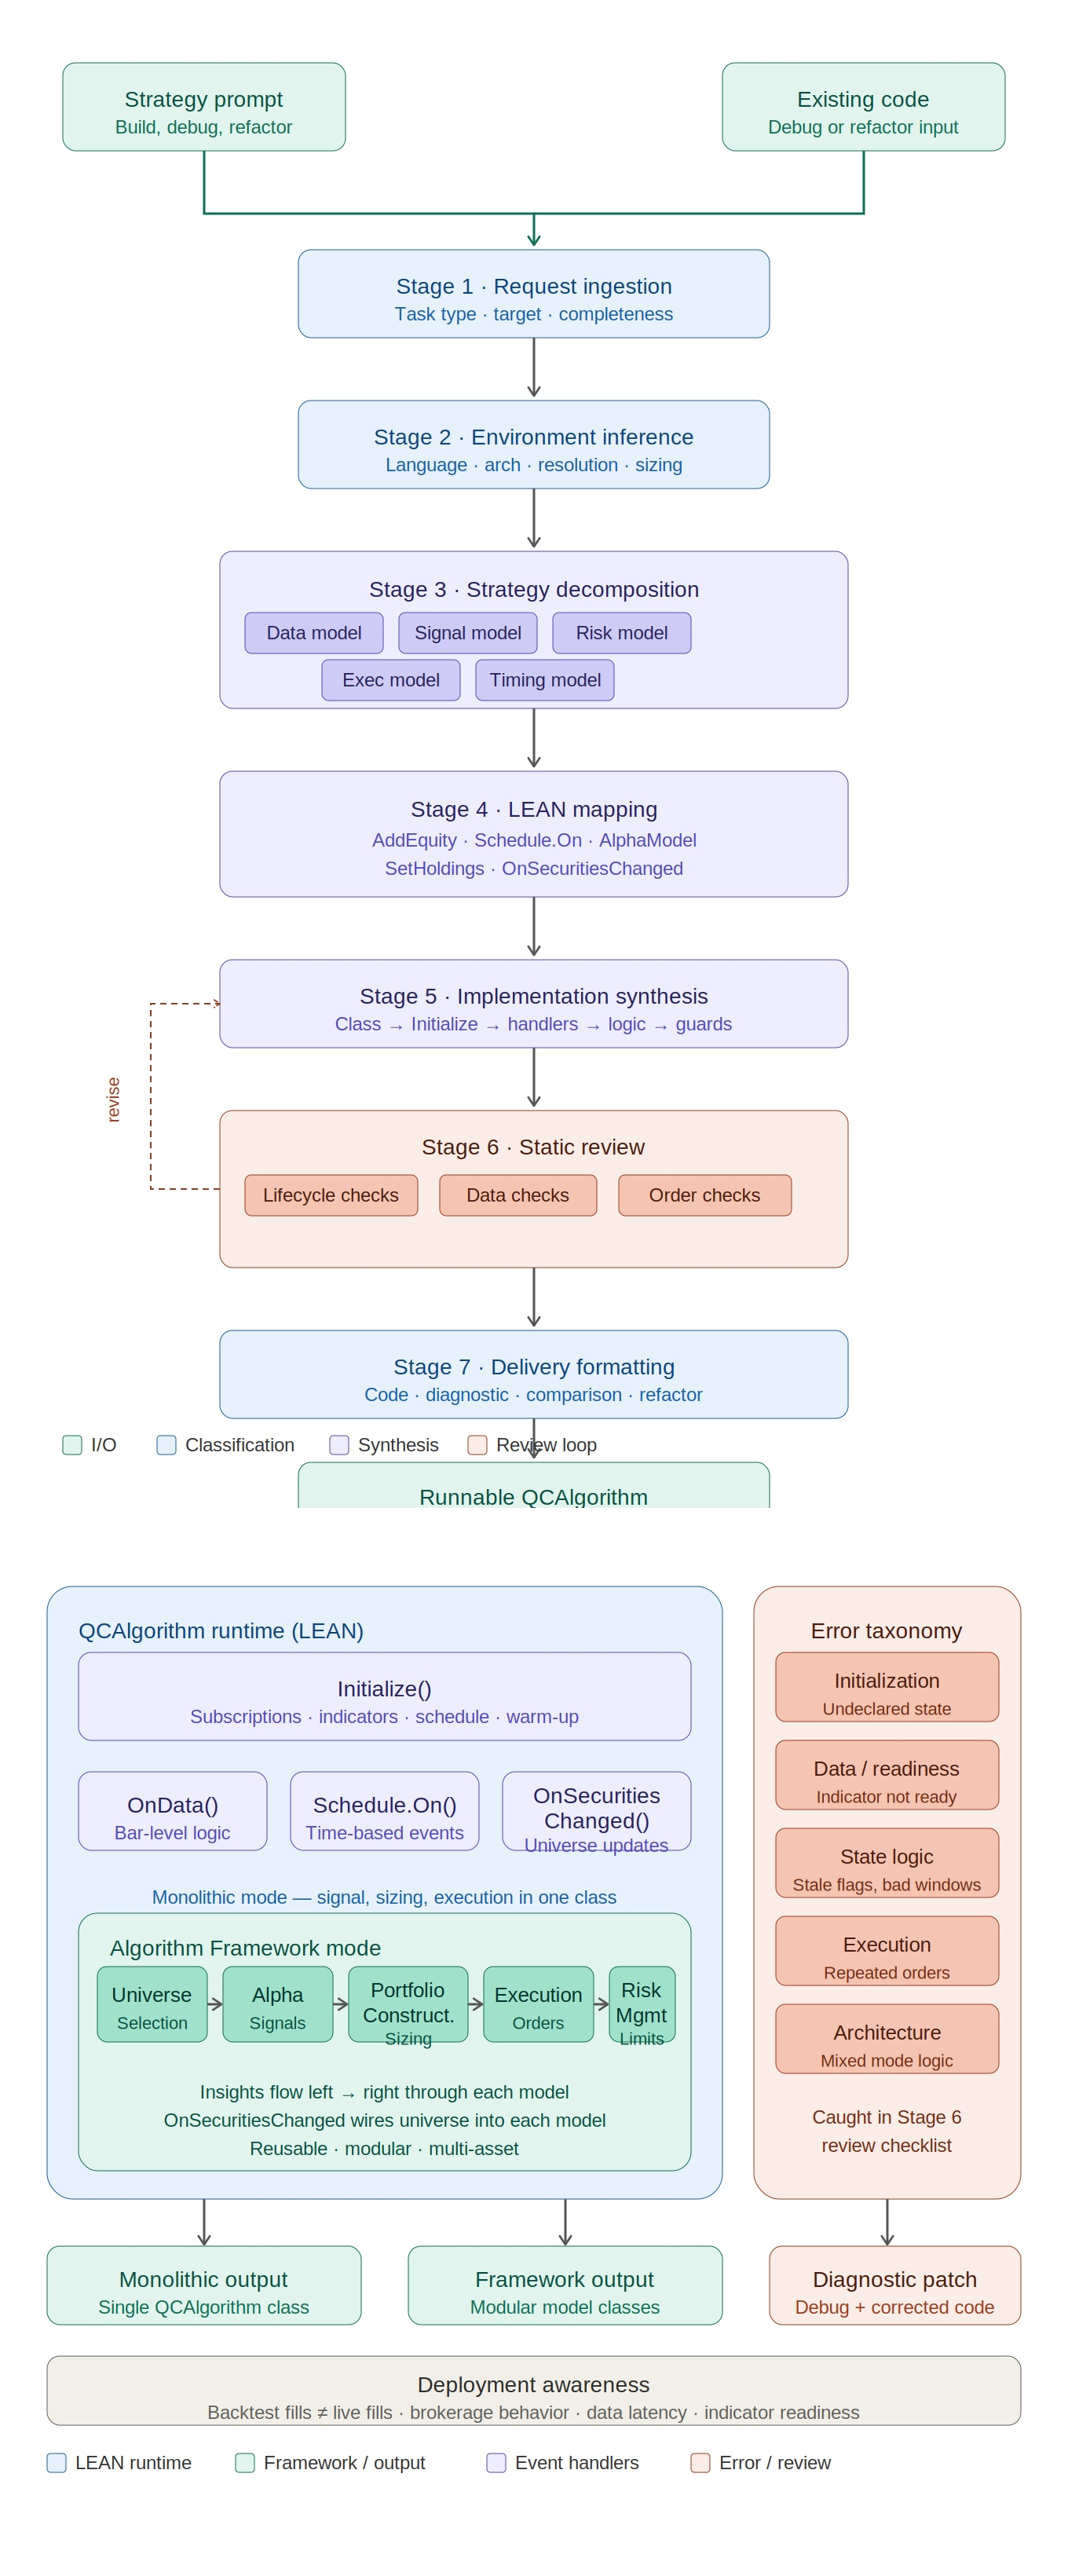

##2.CODE AND IMPLEMENTATION

In [2]:
# ============================================================
#  QuantConnect Code Generator Agent
#  Paste this into a Google Colab notebook and run each cell.
#
#  This agent implements the 7-stage LEAN-specialist pipeline:
#  Request Ingestion → Environment Inference → Strategy
#  Decomposition → LEAN Mapping → Implementation Synthesis →
#  Static Review → Delivery Formatting
# ============================================================


# ── CELL 1: Install dependencies ──────────────────────────
!pip install anthropic -q


# ── CELL 2: Imports & API key ─────────────────────────────
import anthropic
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))
MODEL  = "claude-haiku-4-5-20251001"


# ── CELL 3: Core runner ───────────────────────────────────

def run_stage(stage_name: str, system_prompt: str, user_message: str) -> str:
    """
    Send one stage request to Claude and stream-print the response.
    Each stage is a fresh, focused call with its own system prompt.
    """
    print(f"\n{'='*62}")
    print(f"  {stage_name}")
    print(f"{'='*62}")

    response = client.messages.create(
        model=MODEL,
        max_tokens=2048,
        system=system_prompt,
        messages=[{"role": "user", "content": user_message}]
    )
    result = response.content[0].text
    print(result)
    return result


# ── CELL 4: Stage functions ───────────────────────────────

# ── Stage 1: Request Ingestion ────────────────────────────
def stage1_ingest(user_request: str) -> str:
    system = """You are Stage 1 of a QuantConnect Code Generator Agent.
Your job is REQUEST INGESTION.

Classify the incoming request across three dimensions:

TASK TYPE:
  - build     : generate a new algorithm from a description
  - debug     : diagnose and fix faulty LEAN code
  - refactor  : restructure existing code for maintainability
  - explain   : explain a QuantConnect concept or behavior
  - optimize  : improve performance or robustness of existing code

EXECUTION TARGET:
  - QuantConnect cloud IDE
  - local LEAN CLI
  - Python (default)
  - C#

COMPLETENESS REQUIREMENT:
  - complete algorithm : full runnable QCAlgorithm class
  - snippet           : targeted code fragment
  - architecture      : structural template with placeholders
  - diagnostic patch  : corrected version of broken code

Then extract any EXPLICIT CONSTRAINTS stated by the user:
  asset class · resolution · rebalance frequency · risk controls ·
  architecture preference (monolithic vs Algorithm Framework) · language

Output under these exact headings. Be concise and structured."""

    user = f"Classify and extract constraints from this request:\n\n{user_request}"
    return run_stage("STAGE 1 · Request ingestion", system, user)


# ── Stage 2: Environment Inference ────────────────────────
def stage2_infer(ingestion_output: str, user_request: str) -> str:
    system = """You are Stage 2 of a QuantConnect Code Generator Agent.
Your job is ENVIRONMENT INFERENCE.

Given the classified request, fill in any missing parameters using
conservative, explicit defaults. Output a complete environment
specification table with these columns:
  DIMENSION | INFERRED VALUE | SOURCE (explicit / default)

Dimensions to cover:
  Language         → Python unless C# is requested
  Architecture     → Monolithic for simple/single-asset;
                     Algorithm Framework for modular/multi-asset
  Data resolution  → Daily for concept examples;
                     Minute for intraday / open-close logic
  Position sizing  → Equal-weight or fixed-fraction unless specified
  Risk controls    → Only if requested or obviously needed
  Warm-up period   → Infer from any indicator periods mentioned
  Date range       → Use 2020-01-01 to 2023-12-31 as safe default

After the table, write one sentence explaining your architecture choice."""

    user = (
        f"Original request:\n{user_request}\n\n"
        f"Ingestion output:\n{ingestion_output}\n\n"
        f"Produce the full environment specification."
    )
    return run_stage("STAGE 2 · Environment inference", system, user)


# ── Stage 3: Strategy Decomposition ──────────────────────
def stage3_decompose(ingestion_output: str, environment_output: str,
                     user_request: str) -> str:
    system = """You are Stage 3 of a QuantConnect Code Generator Agent.
Your job is STRATEGY DECOMPOSITION.

Break the request into six implementation primitives:

  DATA MODEL    – what assets and fields must be subscribed;
                  symbols, asset classes, resolutions
  STATE MODEL   – what values must persist across events;
                  indicators, rolling windows, regime flags
  SIGNAL MODEL  – how entries and exits are derived;
                  indicator logic, thresholds, crossovers, rankings
  EXECUTION MODEL – how targets become orders;
                  order types, timing, rebalance cadence
  RISK MODEL    – what limits prevent pathological behavior;
                  stop-loss, max exposure, drawdown caps
  TIMING MODEL  – whether reactions are bar-driven, event-driven,
                  or scheduled

Flag any ambiguity with [AMBIGUOUS: <question for user>].
Be precise and implementation-oriented. No code yet."""

    user = (
        f"Request:\n{user_request}\n\n"
        f"Environment spec:\n{environment_output}\n\n"
        f"Decompose into the six primitives."
    )
    return run_stage("STAGE 3 · Strategy decomposition", system, user)


# ── Stage 4: LEAN Mapping ────────────────────────────────
def stage4_lean_map(decomposition_output: str,
                    environment_output: str) -> str:
    system = """You are Stage 4 of a QuantConnect Code Generator Agent.
Your job is LEAN MAPPING.

Map every decomposed primitive to its QuantConnect/LEAN equivalent.
Produce a table with columns:
  PRIMITIVE ELEMENT | LEAN CONSTRUCT | LOCATION

Location must be one of:
  Initialize() · OnData() · Schedule.On() callback ·
  OnSecuritiesChanged() · OnOrderEvent() · runtime helper

Cover all standard mappings, for example:
  static symbol set      → AddEquity / AddForex / AddCrypto
  daily rebalance        → Schedule.On(DateRules, TimeRules, callback)
  cross-sectional filter → Universe selection + OnSecuritiesChanged
  technical indicator    → self.SMA / self.EMA / self.RSI + SetWarmUp
  rolling lookback       → RollingWindow or self.History()
  order placement        → MarketOrder / SetHoldings / LimitOrder
  order lifecycle        → OnOrderEvent + order ticket
  modular alpha logic    → Algorithm Framework AlphaModel

Where exact parity is impossible, note the approximation explicitly
and mark it [APPROXIMATION: <explanation>]."""

    user = (
        f"Environment spec:\n{environment_output}\n\n"
        f"Decomposition:\n{decomposition_output}\n\n"
        f"Produce the complete LEAN mapping table."
    )
    return run_stage("STAGE 4 · LEAN mapping", system, user)


# ── Stage 5: Implementation Synthesis ────────────────────
def stage5_synthesize(lean_map_output: str, decomposition_output: str,
                      environment_output: str, user_request: str) -> str:
    system = """You are Stage 5 of a QuantConnect Code Generator Agent.
Your job is IMPLEMENTATION SYNTHESIS.

Generate a complete, runnable QuantConnect Python algorithm.
Follow this exact construction order:
  1. from AlgorithmImports import *
  2. Class declaration (QCAlgorithm subclass)
  3. initialize() method:
       set_start_date / set_end_date / set_cash / set_brokerage_model
       security subscriptions
       indicator and consolidator setup
       scheduled events
       set_warm_up()
       persistent state variables
  4. Event handlers: on_data() / on_securities_changed() / on_order_event()
  5. Scheduled callback methods
  6. Signal logic (clearly separated from execution)
  7. Execution logic (order guards, SetHoldings, Liquidate)
  8. Risk management checks

Annotation rules:
  # [ASSUMPTION] – mark every assumption made due to missing info
  # [PLACEHOLDER] – mark every element needing user customization

Output ONLY the Python code block. No prose before or after."""

    user = (
        f"Original request:\n{user_request}\n\n"
        f"Environment spec:\n{environment_output}\n\n"
        f"Decomposition:\n{decomposition_output}\n\n"
        f"LEAN mapping:\n{lean_map_output}\n\n"
        f"Generate the complete algorithm."
    )
    return run_stage("STAGE 5 · Implementation synthesis", system, user)


# ── Stage 6: Static Review ────────────────────────────────
def stage6_review(code: str, decomposition_output: str,
                  lean_map_output: str) -> str:
    system = """You are Stage 6 of a QuantConnect Code Generator Agent.
Your job is STATIC REVIEW — a three-pass quality check.

PASS A · Lifecycle checks
  - All objects initialized in initialize()?
  - Event handlers named and scoped correctly?
  - Security references stored and reused safely?
  - set_warm_up() present when indicators require it?

PASS B · Data and readiness checks
  - Indicators guarded by .is_ready checks?
  - Resolution consistent with strategy logic?
  - Universe members handled in on_securities_changed()?
  - No reads of slice data for symbols not in the slice?

PASS C · Order and execution checks
  - Duplicate-order or repeated-entry risks?
  - Liquidation guarded against oscillatory re-entry?
  - Holdings and open orders checked before new orders?
  - Backtest-only assumptions clearly marked?

For each pass output:
  OK       – items that pass
  FIX      – specific problem + corrected line or pattern
  WARNING  – potential issue depending on user intent

End with a one-line OVERALL VERDICT: PASS / PASS WITH FIXES / FAIL."""

    user = (
        f"Decomposition (for fidelity check):\n{decomposition_output}\n\n"
        f"LEAN mapping (for API correctness):\n{lean_map_output}\n\n"
        f"Generated code to review:\n{code}"
    )
    return run_stage("STAGE 6 · Static review", system, user)


# ── Stage 7: Delivery Formatting ─────────────────────────
def stage7_deliver(code: str, review_output: str,
                   user_request: str) -> str:
    system = """You are Stage 7 of a QuantConnect Code Generator Agent.
Your job is DELIVERY FORMATTING.

Produce the final deliverable in three sections:

SECTION 1 · FINAL CODE
  Apply every FIX from the static review to produce the clean,
  corrected final algorithm. Output the complete Python code block.
  Remove any redundant comments but keep all [ASSUMPTION] and
  [PLACEHOLDER] markers so the user knows what to verify.

SECTION 2 · IMPLEMENTATION NOTES
  Write 3-5 bullet points explaining:
  - key design decisions and why they were made
  - any [APPROXIMATION] made during LEAN mapping
  - parameters the user is most likely to want to tune
  - known behavioral differences between backtest and live

SECTION 3 · NEXT STEPS
  Write 3 specific, actionable steps the user should take after
  pasting this code into QuantConnect:
  - what to backtest first
  - what logs or charts to inspect
  - what live-trading configuration to review"""

    user = (
        f"Original request:\n{user_request}\n\n"
        f"Static review findings:\n{review_output}\n\n"
        f"Code to finalize:\n{code}"
    )
    return run_stage("STAGE 7 · Delivery formatting", system, user)


# ── CELL 5: Define your request ──────────────────────────
#
#  Replace the string below with your own strategy description,
#  broken code, or refactor request. Examples:
#
#  BUILD:
#    "Build a daily mean-reversion strategy on QQQ. Enter long when
#     the 14-day RSI drops below 30 and exit when it rises above 50.
#     Allocate 80% of capital. Include a 5% stop-loss."
#
#  DEBUG:
#    "My algorithm crashes with AttributeError: 'NoneType' has no
#     attribute 'Current'. Here is the code: ..."
#
#  REFACTOR:
#    "Refactor this monolithic strategy into Algorithm Framework
#     components. Here is the code: ..."

USER_REQUEST = """
Build a QuantConnect algorithm for a dual-momentum strategy on a
small equity universe. Each week, rank SPY, QQQ, IWM, and GLD by
their 12-month trailing return. Go long the top 2 ranked assets,
equally weighted. If the top-ranked asset has a negative 12-month
return, hold cash instead (defensive regime). Rebalance every
Monday at market open. Include a 2% per-position stop-loss.
Use daily resolution.
"""


# ── CELL 6: Run the full agent pipeline ──────────────────

print("\n" + "█"*62)
print("  QuantConnect Code Generator Agent  —  Starting pipeline")
print("█"*62)

# Stage 1 – classify the request
ingestion      = stage1_ingest(USER_REQUEST)

# Stage 2 – fill in missing environment parameters
environment    = stage2_infer(ingestion, USER_REQUEST)

# Stage 3 – break into six implementation primitives
decomposition  = stage3_decompose(ingestion, environment, USER_REQUEST)

# Stage 4 – map every primitive to a LEAN construct
lean_map       = stage4_lean_map(decomposition, environment)

# Stage 5 – synthesize the first-draft algorithm
code_v1        = stage5_synthesize(lean_map, decomposition,
                                   environment, USER_REQUEST)

# Stage 6 – three-pass static review
review         = stage6_review(code_v1, decomposition, lean_map)

# Stage 7 – apply fixes and format the final deliverable
final          = stage7_deliver(code_v1, review, USER_REQUEST)

print("\n" + "█"*62)
print("  PIPELINE COMPLETE")
print("█"*62)


# ── CELL 7: Print final deliverable only ─────────────────

print("\n" + "="*62)
print("  FINAL DELIVERABLE")
print("="*62)
print(final)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 4.9 MB/s eta 0:00:00

██████████████████████████████████████████████████████████████
  QuantConnect Code Generator Agent  —  Starting pipeline
██████████████████████████████████████████████████████████████

  STAGE 1 · Request ingestion
# REQUEST INGESTION CLASSIFICATION

## TASK TYPE
**build** — generate a new algorithm from a description

## EXECUTION TARGET
**QuantConnect cloud IDE** (default; Python unless specified)
- Language: **Python**

## COMPLETENESS REQUIREMENT
**complete algorithm** — full runnable QCAlgorithm class

---

## EXPLICIT CONSTRAINTS EXTRACTED

| Dimension | Constraint |
|-----------|-----------|
| **Asset Class** | Equities (4-asset universe: SPY, QQQ, IWM, GLD) |
| **Resolution** | Daily |
| **Rebalance Frequency** | Weekly (every Monday at market open) |
| **Ranking Logic** | 12-month trailing return |
| **Position Sizing** | Equal weight (top 2 assets) |
| **Defensive Regime** | If top asset has nega